In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import stylia
from stylia import ArticleColors, save_figure
from stylia import CategoricalPalette
stylia.set_format("slide")
stylia.set_style("ersilia")
pal = CategoricalPalette("ersilia")
nc = stylia.NamedColors()

plt.rcParams["figure.dpi"] = 300

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load metadata and pathogen names
metadata = pd.read_csv(os.path.join(REPO_ROOT, "data", "processed", "01_chembl_datasets_all.csv"))
pathogens = pd.read_csv(os.path.join(REPO_ROOT, "config", "pathogens.csv"))
code_to_name = dict(zip(pathogens["code"], pathogens["pathogen"]))
counts = (metadata.groupby("pathogen").size().reset_index(name="n_datasets").sort_values("n_datasets", ascending=True))
counts["name"] = counts["pathogen"].map(code_to_name)

# Load models report
report = pd.read_csv(os.path.join(REPO_ROOT, "output", "results", "09_reports.csv"))

Pathogen: Candida albicans
Processed datasets: 27/31


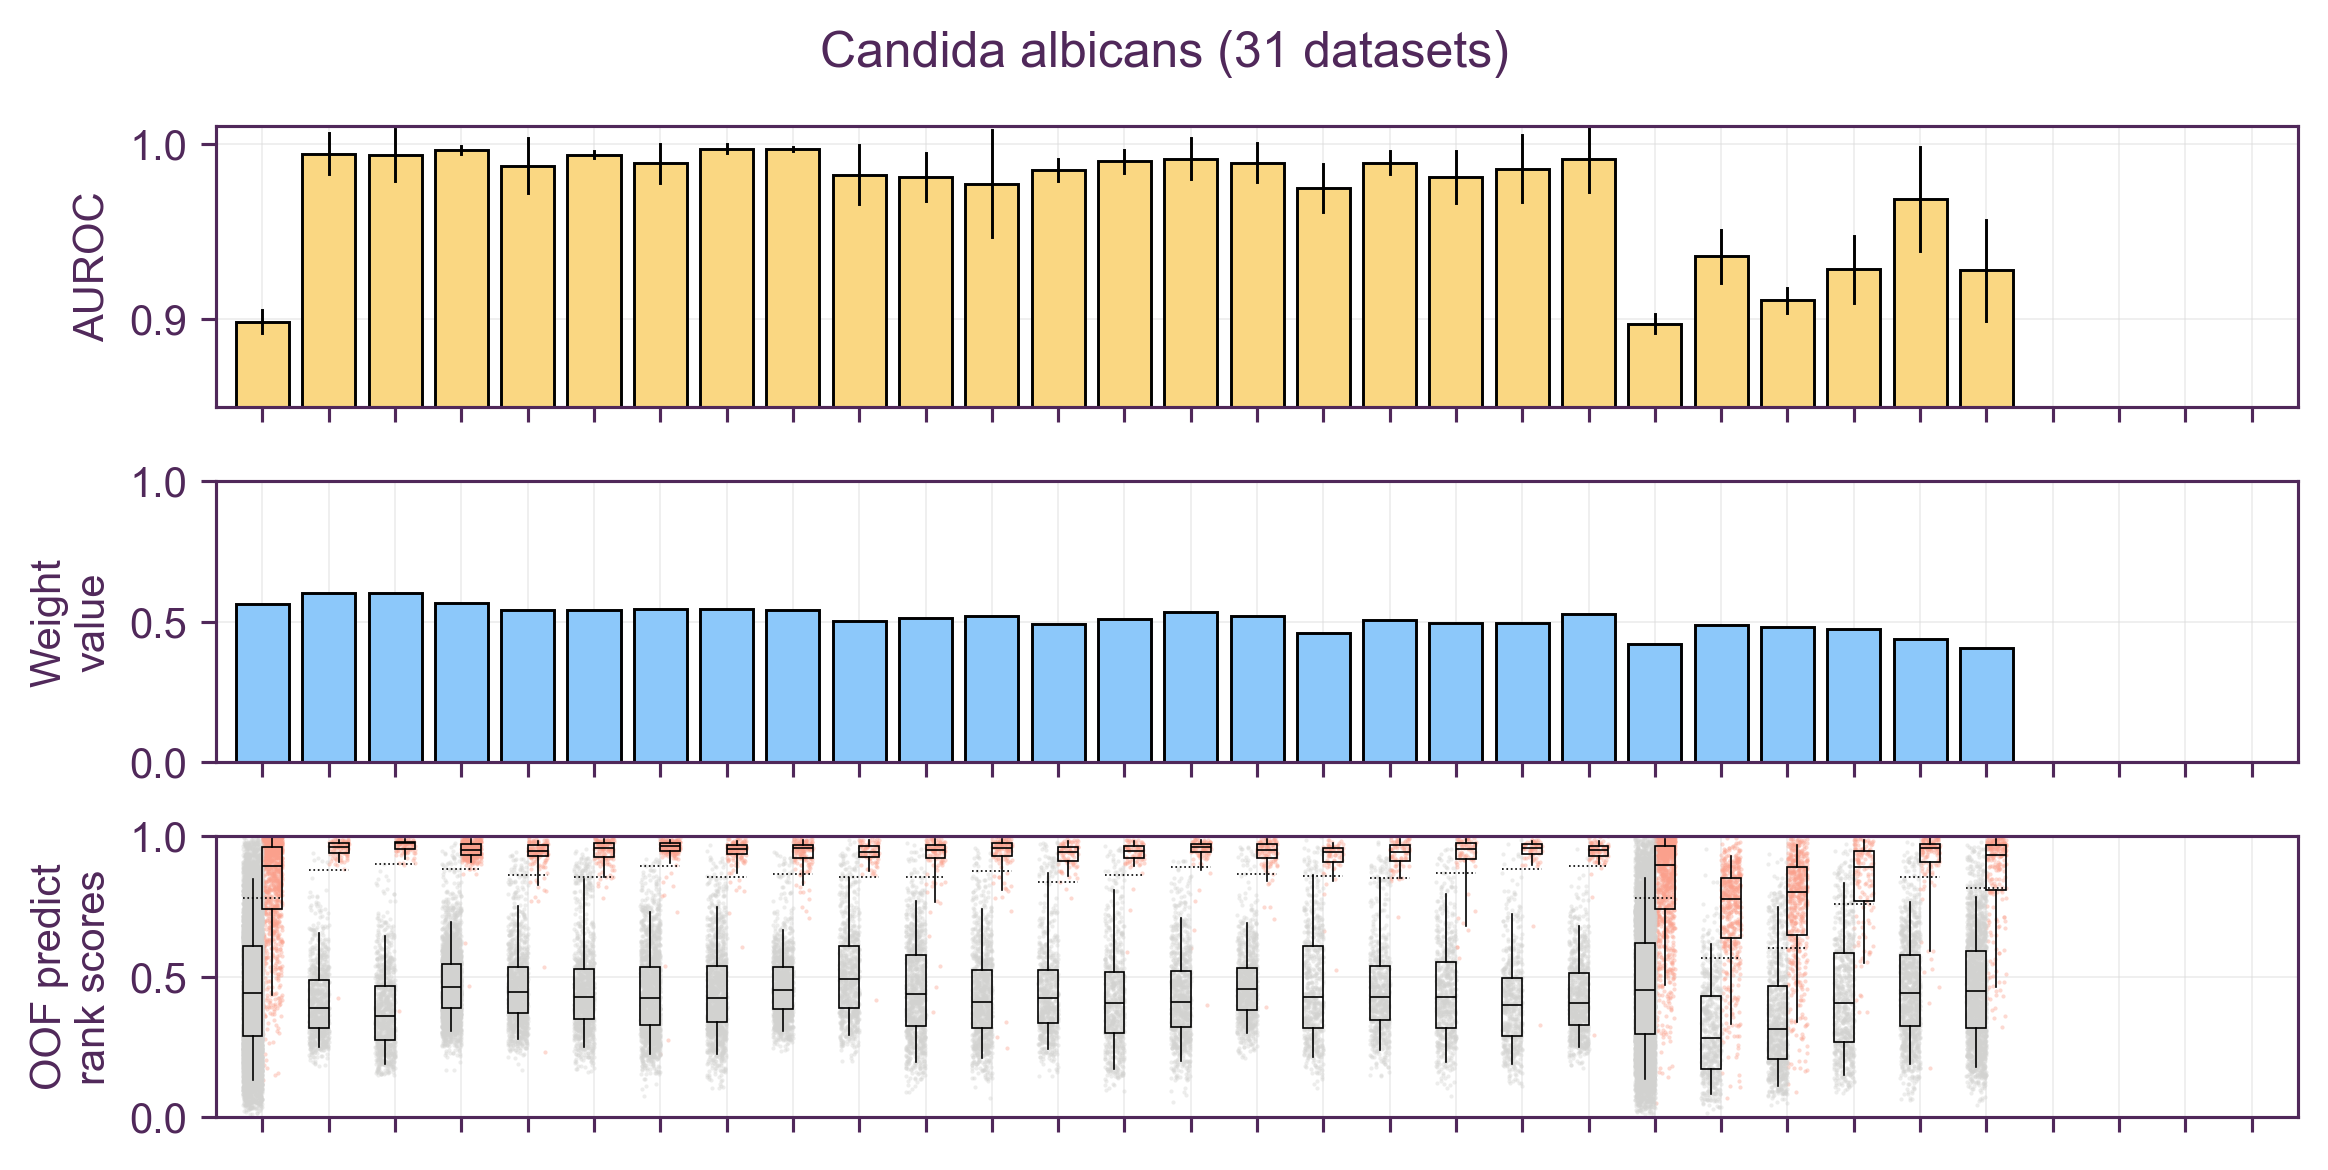

In [153]:
for pathogen in pathogens["code"][1:]:

    # Print information
    print(f"Pathogen: {code_to_name[pathogen]}")
    numb_datasets = counts[counts['pathogen'] == pathogen]['n_datasets'].values[0]
    x = [i for i in range(numb_datasets)]
    report_pathogen = report[report['pathogen'] == pathogen]
    print(f"Processed datasets: {len(report_pathogen)}/{numb_datasets}")

    # Create plot
    fig, axs = stylia.create_figure(3, 1, width=0.6, height=0.3)
    fig.suptitle(f"{code_to_name[pathogen]} ({numb_datasets} datasets)", fontsize=12)

    # AUROCs
    ax = axs.next()
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels([""] * len(x))
    ax.set_ylabel("AUROC")
    ax.set_ylim([0.85, 1.01])
    ax.set_xlim([-0.7, numb_datasets - 0.3])
    aurocs_mean = report_pathogen['auroc_mean'].tolist()
    aurocs_std = report_pathogen['auroc_std'].tolist()
    for i in range(len(aurocs_mean)):
        ax.bar(i, aurocs_mean[i], color=pal.get(2)[1], ec='k', lw=0.7)
        ax.plot([i, i], [aurocs_mean[i] - aurocs_std[i], aurocs_mean[i] + aurocs_std[i]], color='k', lw=0.7)

    # Weights
    ax = axs.next()
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels([""] * len(x))
    ax.set_ylabel("Weight\nvalue")
    ax.set_ylim([0, 1])
    ax.set_xlim([-0.7, numb_datasets - 0.3])
    final_weights = report_pathogen['final_weight'].tolist()
    for i in range(len(final_weights)):
        ax.bar(i, final_weights[i], color=pal.get(8)[4], ec='k', lw=0.7)
    
    # Scores
    ax = axs.next()
    ax.set_xlabel("")
    ax.set_ylabel("OOF predict\nrank scores")
    ax.set_ylim([0, 1])
    ax.set_xlim([-0.7, numb_datasets - 0.3])
    scores_actives = report_pathogen['predict_rank_actives'].tolist()
    scores_inactives = report_pathogen['predict_rank_inactives'].tolist()
    decision_cutoff_rank = report_pathogen['decision_cutoff_rank'].tolist()
    w = 0.15
    rng = np.random.default_rng(42)
    for i in range(len(scores_actives)):
        actives = np.array(scores_actives[i].split(";")).astype(float)
        x_actives = [i+w + rng.uniform(-w, w)/1 for _ in actives]
        inactives = np.array(scores_inactives[i].split(";")).astype(float)
        x_inactives = [i-w + rng.uniform(-w, w)/1 for _ in inactives]
        ax.scatter(x_actives, actives, color=pal.get(8)[3], s=1, alpha=0.4, lw=0)
        ax.scatter(x_inactives, inactives, color=pal.get(8)[7], s=1, alpha=0.4, lw=0)
        ax.plot([i-w*2, i+w*2], [decision_cutoff_rank[i], decision_cutoff_rank[i]], lw=0.4, c='k', linestyle='dotted')
        stats_act   = dict(med=np.median(actives), q1=np.percentile(actives, 25), q3=np.percentile(actives, 75), whislo=np.percentile(actives, 5), 
                         whishi=np.percentile(actives, 95), fliers=[], min=np.min(actives), max=np.max(actives))
        stats_inact = dict(med=np.median(inactives), q1=np.percentile(inactives, 25), q3=np.percentile(inactives, 75), whislo=np.percentile(inactives, 5), 
                         whishi=np.percentile(inactives, 95), fliers=[], min=np.min(inactives), max=np.max(inactives))
        bp = ax.bxp([stats_inact, stats_act], positions=[i-w, i+w],widths=w*2, patch_artist=True, showfliers=False)
        bp["boxes"][0].set_linewidth(0.4)
        bp["boxes"][0].set_facecolor('none')
        bp["boxes"][1].set_linewidth(0.4)
        bp["boxes"][1].set_facecolor('none')
        for element in ["whiskers", "caps", "medians"]:
            for line in bp[element]:
                line.set_color("k")
                line.set_linewidth(0.4)
                if element == "caps":
                    line.set_linewidth(0)
    ax.set_xticks(x)
    if numb_datasets == len(report_pathogen['model_name'].tolist()):
        ax.set_xticklabels(report_pathogen['model_name'].tolist())
    else:
        ax.set_xticklabels([""] * numb_datasets)

        
        

    break